# **Modeling**

---
### **Load Data Processed**

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/gojek_reviews_clean.csv')
df['at'] = pd.to_datetime(df['at'])

print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')
print(f'{df["sentiment"].value_counts()}\n')
print(df.dtypes)
df.head()

== Dataset Profile ==
Baris: 86158
Kolom: 5 

sentiment
1    43079
0    43079
Name: count, dtype: int64

content                     str
clean_content               str
score                     int64
sentiment                 int64
at               datetime64[us]
dtype: object


,content,clean_content,score,sentiment,at
0,Mantap,bagus,4,1,2022-09-22 13:07:39
1,Oke,oke,5,1,2023-07-29 21:58:42
2,Lag pada aplikasi saat pemesanan dan tidak bis...,lag aplikasi mesan tidak mesan padahal masuk p...,1,0,2023-02-18 13:28:52
3,Dengan Aplikasi Gojek Saya Merasa Istimewa Sem...,aplikasi rasa istimewa semangat juang doa baik,5,1,2022-11-19 15:38:25
4,Akhirnya terhapus juga akun saya banyak kebij...,akhir hapus akun banyak bijak tidak sesuai,1,0,2023-11-23 09:10:34


---
## **Train / Validation / Test Split**

In [2]:
from sklearn.model_selection import train_test_split

X = df['clean_content'].to_numpy(dtype=str)
y = df['sentiment'].to_numpy(dtype=int)

# Split 1
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split 2
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')

Train : 68926 (80.0%)
Val   : 8616 (10.0%)
Test  : 8616 (10.0%)


---
## **Tokenizing**

Fit tokenizer **hanya pada data train** (mencegah data leakage), then transform ke semua set.

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Hyperparameter
MAX_VOCAB = 20000  # Ambil 20K kata paling sering

# Fit tokenizer HANYA pada train
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Transform semua set
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [4]:
# Info
vocab_size = len(tokenizer.word_index) + 1
print(f'Total vocabulary: {len(tokenizer.word_index)}')
print(f'Vocab digunakan (MAX_VOCAB): {MAX_VOCAB}')
print(f'\nContoh tokenizing:')
print(f'  Teks  : {X_train[0]}')
print(f'  Angka : {X_train_seq[0]}')

Total vocabulary: 32546
Vocab digunakan (MAX_VOCAB): 20000

Contoh tokenizing:
  Teks  : hei aplikator tarif mahal mitra driver nasib prihatin perhati mitra lapang jangan jajah negeri sendiri
  Angka : [3970, 596, 189, 23, 252, 5, 1232, 3278, 528, 252, 1135, 56, 1432, 1136, 103]


---
## **Padding**

Menyamakan panjang semua sequence agar bisa diproses LSTM.

In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tentukan MAX_LEN dari distribusi panjang teks di train
train_lengths = [len(seq) for seq in X_train_seq]
print(f'Panjang sequence (train):')
print(f'  Mean  : {np.mean(train_lengths):.1f}')
print(f'  Median: {np.median(train_lengths):.1f}')
print(f'  Max   : {np.max(train_lengths)}')
print(f'  95th  : {np.percentile(train_lengths, 95):.0f}')

# Gunakan persentil 95 sebagai MAX_LEN (cover 95% data tanpa terlalu panjang)
MAX_LEN = int(np.percentile(train_lengths, 95))
print(f'\nMAX_LEN dipilih: {MAX_LEN}')

# Pad semua set
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nShape setelah padding:')
print(f'  Train : {X_train_pad.shape}')
print(f'  Val   : {X_val_pad.shape}')
print(f'  Test  : {X_test_pad.shape}')

Panjang sequence (train):
  Mean  : 7.5
  Median: 4.0
  Max   : 65
  95th  : 26

MAX_LEN dipilih: 26

Shape setelah padding:
  Train : (68926, 26)
  Val   : (8616, 26)
  Test  : (8616, 26)


---
## **Baseline Model: DNN (Dense Neural Network)**

### **Build Model**

In [6]:
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, Dense, Dropout
)

In [7]:
EMBED_DIM = 64

model_dnn = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),   # Rata-rata semua embedding → hilangkan info urutan
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='baseline_dnn')
model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_dnn.summary()

d:\Icam\Bootcamp DS ML\Belajar Coding\Python\File Python\Assignment\gojek-sentiment-analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "baseline_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model_dnn.build(input_shape=(None, MAX_LEN))
model_dnn.summary()

Model: "baseline_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 26, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,273 (4.91 MB)

 Trainable params: 1,286,273 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

### **Train Model**

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_dnn = model_dnn.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8642 - loss: 0.3358 - val_accuracy: 0.9148 - val_loss: 0.2358
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9161 - loss: 0.2428 - val_accuracy: 0.9160 - val_loss: 0.2330
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9246 - loss: 0.2215 - val_accuracy: 0.9201 - val_loss: 0.2236
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9327 - loss: 0.2013 - val_accuracy: 0.9155 - val_loss: 0.2363
Epoch 5/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9374 - loss: 0.1882 - val_accuracy: 0.9182 - val_loss: 0.2338
Epoch 6/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9397 - loss: 0.1802 - val_accuracy: 0.9166 - val_loss: 0.2397
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


### **Evaluasi Test Set**

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi
y_pred_prob_dnn = model_dnn.predict(X_test_pad)
y_pred_dnn = (y_pred_prob_dnn > 0.5).astype(int).flatten()

# Loss & Accuracy
test_loss, test_acc = model_dnn.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}\n')

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred_dnn, target_names=['Negatif', 'Positif']))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_dnn))

270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step
Test Loss    : 0.2438
Test Accuracy: 0.9175

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.90      0.93      0.92      4308
     Positif       0.93      0.90      0.92      4308

    accuracy                           0.92      8616
   macro avg       0.92      0.92      0.92      8616
weighted avg       0.92      0.92      0.92      8616

Confusion Matrix:
[[4019  289]
 [ 422 3886]]


### **Visualisations**

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    rc={
        "figure.figsize": (8, 5),
        "axes.edgecolor": "#EAEAEA",
        "grid.color": "#686D76",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11
    }
)

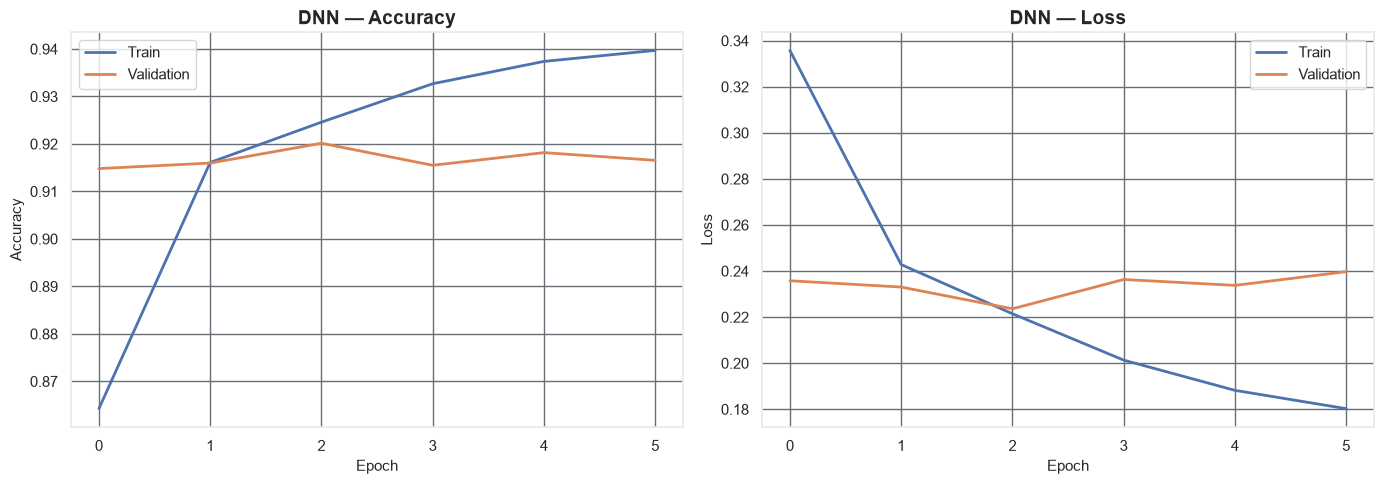

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(history_dnn.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_dnn.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('DNN — Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# --- Loss ---
axes[1].plot(history_dnn.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_dnn.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('DNN — Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/05_DNN_Accuracy_Loss.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **Main Model: Bidirectional LSTM (BiLSTM)**

### **Build Model**

In [14]:
from tensorflow.keras.layers import Bidirectional, LSTM, SpatialDropout1D

model_bilstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='main_bilstm')

model_bilstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_bilstm.summary()

d:\Icam\Bootcamp DS ML\Belajar Coding\Python\File Python\Assignment\gojek-sentiment-analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "main_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model_bilstm.build(input_shape=(None, MAX_LEN))
model_bilstm.summary()

Model: "main_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 26, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 26, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

### **Train Model**

In [16]:
early_stop_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop_bilstm],
    verbose=1
)

Epoch 1/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9023 - loss: 0.2660 - val_accuracy: 0.9226 - val_loss: 0.2168
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9315 - loss: 0.2049 - val_accuracy: 0.9241 - val_loss: 0.2166
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.9410 - loss: 0.1809 - val_accuracy: 0.9219 - val_loss: 0.2264
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9477 - loss: 0.1630 - val_accuracy: 0.9219 - val_loss: 0.2407
Epoch 5/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.9527 - loss: 0.1471 - val_accuracy: 0.9200 - val_loss: 0.2577
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


### **Evaluasi Test Set**

In [17]:
# Prediksi
y_pred_prob_bilstm = model_bilstm.predict(X_test_pad)
y_pred_bilstm = (y_pred_prob_bilstm > 0.5).astype(int).flatten()

# Loss & Accuracy
test_loss_bi, test_acc_bi = model_bilstm.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Loss    : {test_loss_bi:.4f}')
print(f'Test Accuracy: {test_acc_bi:.4f}\n')

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred_bilstm, target_names=['Negatif', 'Positif']))

# Confusion Matrix
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_bilstm))

270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Loss    : 0.2384
Test Accuracy: 0.9204

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.90      0.95      0.92      4308
     Positif       0.95      0.89      0.92      4308

    accuracy                           0.92      8616
   macro avg       0.92      0.92      0.92      8616
weighted avg       0.92      0.92      0.92      8616

Confusion Matrix:
[[4097  211]
 [ 475 3833]]


### **Visualisations**

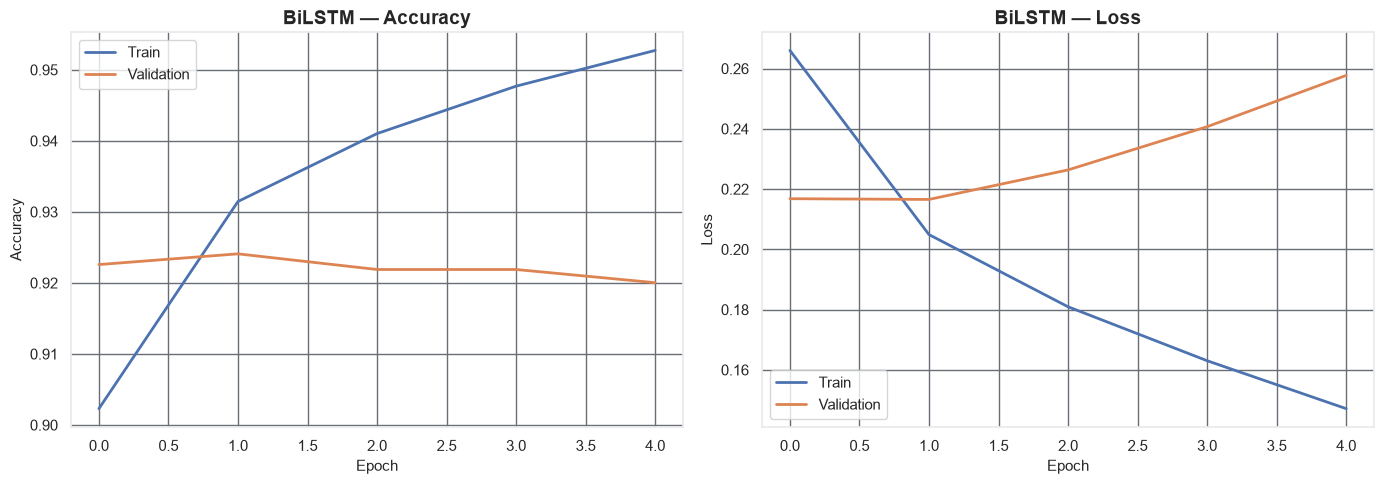

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(history_bilstm.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_bilstm.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('BiLSTM — Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# --- Loss ---
axes[1].plot(history_bilstm.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_bilstm.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('BiLSTM — Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/06_BiLSTM_Accuracy_Loss.png', dpi=150, bbox_inches='tight')
plt.show()

### **Comparison DNN vs BiLSTM**

In [20]:
comparison = pd.DataFrame({
    'Model': ['DNN (Baseline)', 'BiLSTM (Main)'],
    'Test Loss': [test_loss, test_loss_bi],
    'Test Accuracy': [test_acc, test_acc_bi],
})

comparison['Test Accuracy'] = comparison['Test Accuracy'].map('{:.4f}'.format)
comparison['Test Loss'] = comparison['Test Loss'].map('{:.4f}'.format)

print('=' * 50)
print('       PERBANDINGAN MODEL')
print('=' * 50)
print(comparison.to_string(index=False))
print('=' * 50)

       PERBANDINGAN MODEL
         Model Test Loss Test Accuracy
DNN (Baseline)    0.2438        0.9175
 BiLSTM (Main)    0.2384        0.9204


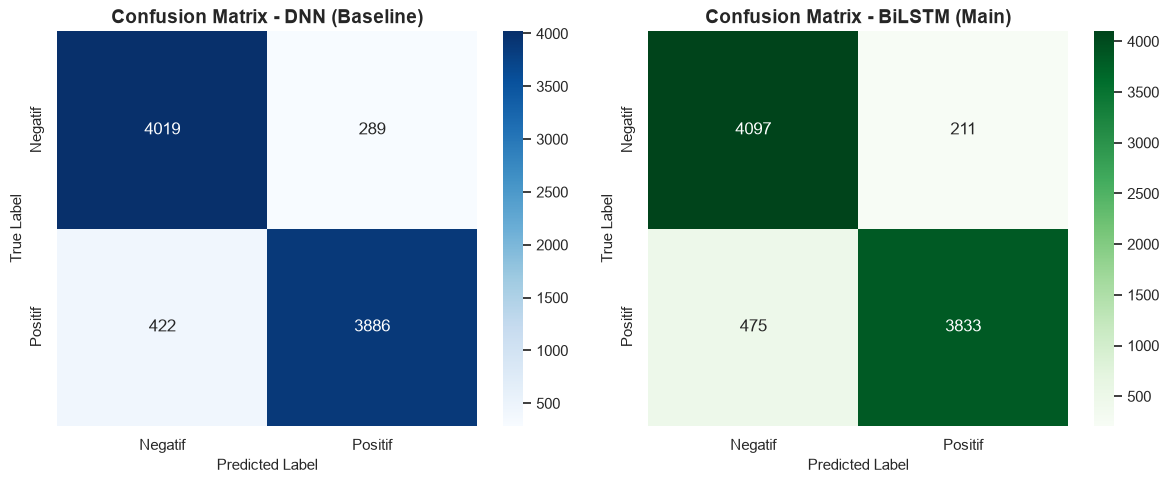

In [21]:
cm_dnn = confusion_matrix(y_test, y_pred_dnn)
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot Confusion Matrix DNN ---
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
axes[0].set_title('Confusion Matrix - DNN (Baseline)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# --- Plot Confusion Matrix BiLSTM ---
sns.heatmap(cm_bilstm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
axes[1].set_title('Confusion Matrix - BiLSTM (Main)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../assets/07_Models_Confusion_Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## **Hyperparameter Tuning (Keras Tuner)**

Mencari kombinasi parameter yang paling optimal untuk model BiLSTM menggunakan `RandomSearch`. Parameter yang akan diuji meliputi ukuran dimensi embedding, unit LSTM, persentase dropout, unit dense layer, dan learning rate.

In [22]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

### **Build Model**

In [23]:
def build_model(hp):
    model = Sequential()
    # Tuning ukuran dimensi embedding (pilih antara 64 atau 128)
    hp_embed_dim = hp.Choice('embed_dim', values=[64, 128])
    model.add(Embedding(input_dim=MAX_VOCAB, output_dim=hp_embed_dim, input_length=MAX_LEN))
    
    # Tuning persentase dropout level embedding (antara 0.2 s/d 0.5)
    hp_spatial_dropout = hp.Float('spatial_dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(SpatialDropout1D(hp_spatial_dropout))
    
    # Tuning jumlah unit LSTM (kelipatan 32, dari 32 s/d 128)
    hp_lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    model.add(Bidirectional(LSTM(hp_lstm_units)))
    
    # Tuning unit di Dense layer (32 atau 64)
    hp_dense_units = hp.Int('dense_units', min_value=32, max_value=64, step=32)
    model.add(Dense(hp_dense_units, activation='relu'))
    
    # Tuning persentase dropout (antara 0.2 s/d 0.5)
    hp_dropout = hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)
    model.add(Dropout(hp_dropout))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # Tuning learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    return model

### **Inisiasi Tuner**

In [24]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Mencoba 5 kombinasi secara acak (bisa dinaikkan jika ada waktu luang)
    executions_per_trial=1,
    directory='hyperparam_tuning',
    project_name='bilstm_sentiment'
)

# Ringkasan batasan pencarian
tuner.search_space_summary()

Reloading Tuner from hyperparam_tuning\bilstm_sentiment\tuner0.json
Search space summary
Default search space size: 6
embed_dim (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128], 'ordered': True}
spatial_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lstm_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 64, 'step': 32, 'sampling': 'linear'}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [28]:
early_stop_tuner = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Mulai pencarian parameter terbaik!
tuner.search(
    X_train_pad, y_train,
    epochs=10, # Batasi 10 epoch per percobaan agar lebih cepat
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop_tuner],
    batch_size=128,
    verbose=1
)

In [29]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=== HYPERPARAMETER TERBAIK ===")
print(f"Embedding Dimension: {best_hps.get('embed_dim')}")
print(f"Spatial Dropout    : {best_hps.get('spatial_dropout')}")
print(f"LSTM Units         : {best_hps.get('lstm_units')}")
print(f"Dense Units        : {best_hps.get('dense_units')}")
print(f"Dropout Rate       : {best_hps.get('dropout')}")
print(f"Learning Rate      : {best_hps.get('learning_rate')}")

=== HYPERPARAMETER TERBAIK ===
Embedding Dimension: 128
Spatial Dropout    : 0.4
LSTM Units         : 64
Dense Units        : 64
Dropout Rate       : 0.30000000000000004
Learning Rate      : 0.001


---
## **Re-train BiLSTM**

Latih ulang model final dengan jumlah epoch maksimal menggunakan parameter terbaik

In [30]:
from sklearn.metrics import classification_report

best_model = tuner.hypermodel.build(best_hps)

history_best_model = best_model.fit(
    X_train_pad, y_train,
    epochs=20,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop_tuner],
    batch_size=128,
    verbose=1
)

# Prediksi test set
y_pred_prob_best = best_model.predict(X_test_pad)
y_pred_best = (y_pred_prob_best > 0.5).astype(int).flatten()

print('\nClassification Report (Tuned Model):')
print(classification_report(y_test, y_pred_best, target_names=['Negatif', 'Positif']))

Epoch 1/20


d:\Icam\Bootcamp DS ML\Belajar Coding\Python\File Python\Assignment\gojek-sentiment-analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


539/539 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9012 - loss: 0.2680 - val_accuracy: 0.9234 - val_loss: 0.2171
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9299 - loss: 0.2066 - val_accuracy: 0.9232 - val_loss: 0.2158
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.9397 - loss: 0.1839 - val_accuracy: 0.9231 - val_loss: 0.2248
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9463 - loss: 0.1651 - val_accuracy: 0.9219 - val_loss: 0.2310
Epoch 5/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9513 - loss: 0.1503 - val_accuracy: 0.9212 - val_loss: 0.2477
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report (Tuned Model):
              precision    recall  f1-score   support

     Negatif       0.89      0.95      0.92      4308
     Positif       0.95      0.89      0.92      4308

    accuracy                           0.92      8616
   macro avg       0.92      0.92      0.92      8616
weighted a

In [31]:
test_loss_best, test_acc_best = best_model.evaluate(X_test_pad, y_test, verbose=0)
print(f'Test Loss    : {test_loss_best:.4f}')
print(f'Test Accuracy: {test_acc_best:.4f}\n')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))

Test Loss    : 0.2389
Test Accuracy: 0.9199

Confusion Matrix:
[[4105  203]
 [ 487 3821]]


### **Comparison Models**

In [32]:
comparison = pd.DataFrame({
    'Model': ['DNN (Baseline)', 'BiLSTM (Main)', 'BiLSTM (Tuned)'],
    'Test Loss': [test_loss, test_loss_bi, test_loss_best],
    'Test Accuracy': [test_acc, test_acc_bi, test_acc_best],
})

comparison['Test Accuracy'] = comparison['Test Accuracy'].map('{:.4f}'.format)
comparison['Test Loss'] = comparison['Test Loss'].map('{:.4f}'.format)

print('=' * 50)
print('       PERBANDINGAN MODEL')
print('=' * 50)
print(comparison.to_string(index=False))
print('=' * 50)

       PERBANDINGAN MODEL
         Model Test Loss Test Accuracy
DNN (Baseline)    0.2438        0.9175
 BiLSTM (Main)    0.2384        0.9204
BiLSTM (Tuned)    0.2389        0.9199


In [33]:
print('Confusion Matrix:\n')
print('= DNN (Baseline) =')
print(confusion_matrix(y_test, y_pred_dnn),'\n')
print('= BiLSTM (Default) =')
print(confusion_matrix(y_test, y_pred_bilstm),'\n')
print('= BiLSTM (Tuned) =')
print(confusion_matrix(y_test, y_pred_best))

Confusion Matrix:

= DNN (Baseline) =
[[4019  289]
 [ 422 3886]] 

= BiLSTM (Default) =
[[4097  211]
 [ 475 3833]] 

= BiLSTM (Tuned) =
[[4105  203]
 [ 487 3821]]


---
## **Save Model**

In [34]:
import pickle

# 1. Simpan Model BiLSTM (Main Model)
model_bilstm.save('../models/bilstm_sentiment_model_default.keras')
best_model.save('../models/bilstm_sentiment_model_tuned.keras')

# 2. Simpan Tokenizer
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 3. Simpan nilai MAX_LEN agar saat prediksi teks baru kita tahu batas padding-nya
with open('../models/max_len.pkl', 'wb') as f:
    pickle.dump(MAX_LEN, f)

print("✅ Model BiLSTM, Tokenizer, dan MAX_LEN berhasil disimpan di folder 'models/'")

✅ Model BiLSTM, Tokenizer, dan MAX_LEN berhasil disimpan di folder 'models/'


---
## **Prediksi Sentiment ke Seluruh Dataset**

In [35]:
# Inference ke seluruh dataset (bukan cuma test set)
X_full = df['clean_content'].to_numpy(dtype=str)
X_full_seq = tokenizer.texts_to_sequences(X_full)
X_full_pad = pad_sequences(X_full_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_pred_full_prob = model_bilstm.predict(X_full_pad)
df['predicted_sentiment'] = (y_pred_full_prob > 0.5).astype(int)

print(df[['at', 'sentiment', 'predicted_sentiment']].head())
print(f'\nTotal data: {len(df)}')

2693/2693 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
                   at  sentiment  predicted_sentiment
0 2022-09-22 13:07:39          1                    1
1 2023-07-29 21:58:42          1                    1
2 2023-02-18 13:28:52          0                    0
3 2022-11-19 15:38:25          1                    1
4 2023-11-23 09:10:34          0                    0

Total data: 86158


In [36]:
# Agregasi mingguan
df['week'] = df['at'].dt.to_period('W').dt.start_time

trend = df.groupby(['week', 'predicted_sentiment']).size().unstack(fill_value=0)
trend.columns = ['Negative', 'Positive']
trend['Total'] = trend['Negative'] + trend['Positive']
trend['Negative_Ratio'] = trend['Negative'] / trend['Total']

print(trend.head(10))
print(f'\nTotal minggu: {len(trend)}')
print(f'Periode: {trend.index.min()} - {trend.index.max()}')

            Negative  Positive  Total  Negative_Ratio
week                                                 
2021-11-01       328       330    658        0.498480
2021-11-08       832       777   1609        0.517091
2021-11-15       612       677   1289        0.474787
2021-11-22       636       689   1325        0.480000
2021-11-29       659       711   1370        0.481022
2021-12-06       791       694   1485        0.532660
2021-12-13       644       569   1213        0.530915
2021-12-20       479       457    936        0.511752
2021-12-27       530       436    966        0.548654
2022-01-03       419       505    924        0.453463

Total minggu: 118
Periode: 2021-11-01 00:00:00 - 2024-01-29 00:00:00


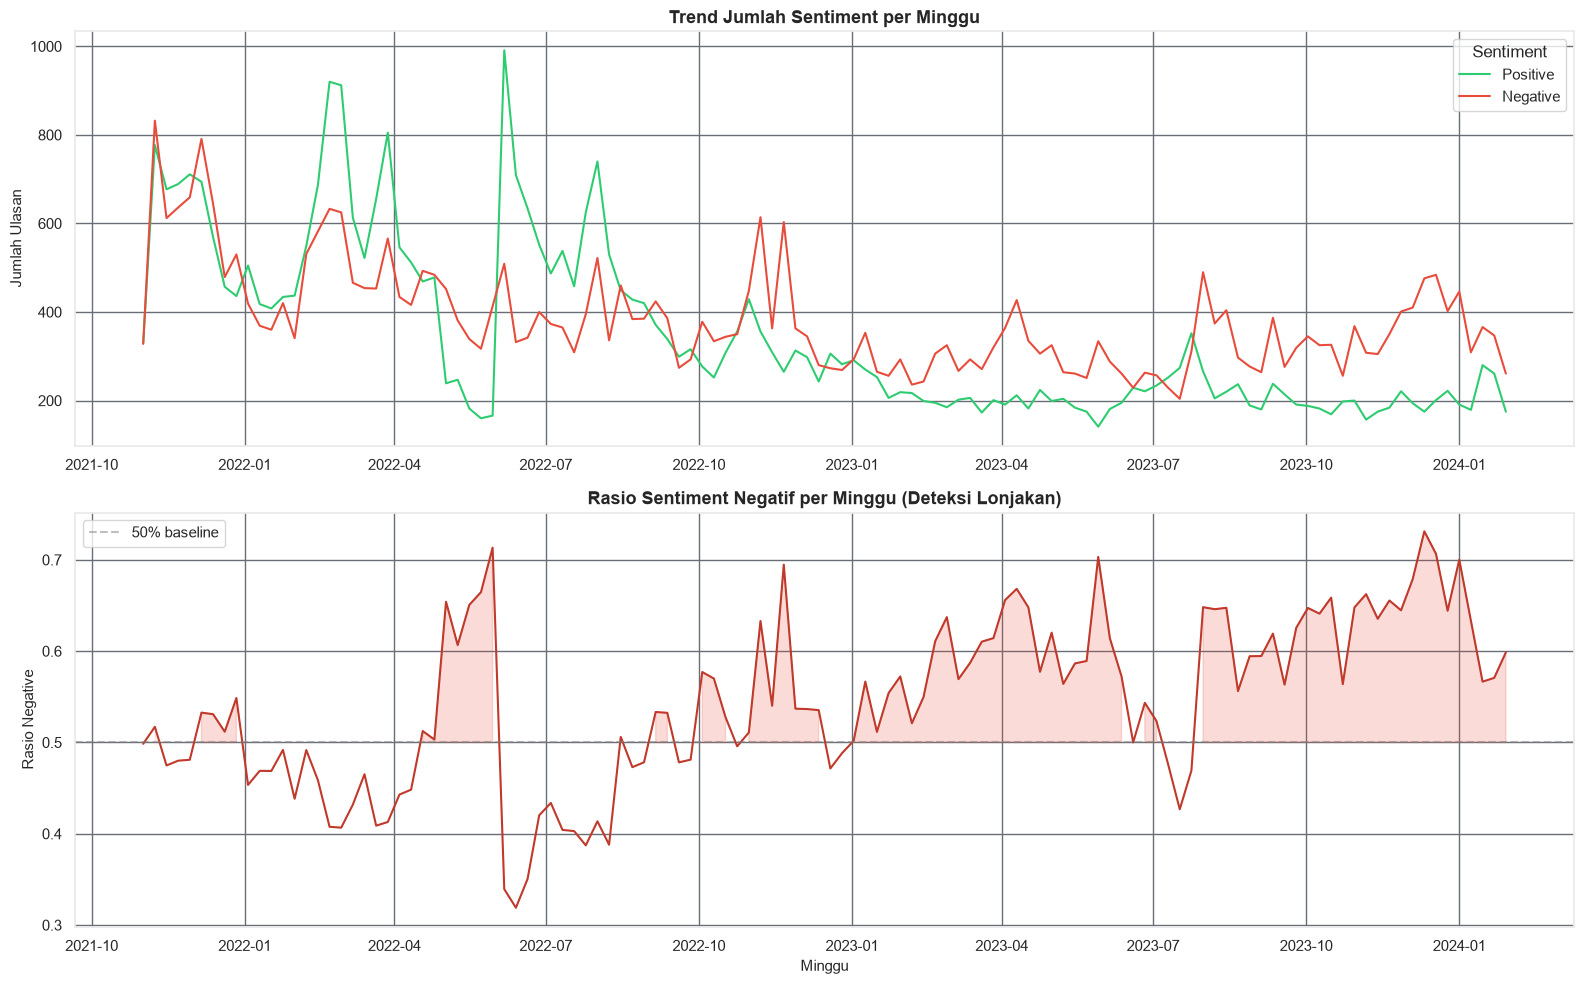

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Jumlah Positive vs Negative per minggu
trend_melted = trend[['Positive', 'Negative']].reset_index().melt(
    id_vars='week', var_name='Sentiment', value_name='Jumlah'
)

sns.lineplot(
    data=trend_melted, x='week', y='Jumlah', hue='Sentiment',
    palette={'Positive': '#2ecc71', 'Negative': '#e74c3c'},
    linewidth=1.5, ax=axes[0]
)
axes[0].set_title('Trend Jumlah Sentiment per Minggu', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Ulasan')
axes[0].set_xlabel('')

# Plot 2: Rasio Negative (untuk deteksi lonjakan)
sns.lineplot(
    data=trend, x=trend.index, y='Negative_Ratio',
    color='#c0392b', linewidth=1.5, ax=axes[1]
)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].fill_between(
    trend.index, trend['Negative_Ratio'], 0.5,
    where=(trend['Negative_Ratio'] > 0.5),
    color='#e74c3c', alpha=0.2
)
axes[1].set_title('Rasio Sentiment Negatif per Minggu (Deteksi Lonjakan)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Rasio Negative')
axes[1].set_xlabel('Minggu')
axes[1].legend()

plt.tight_layout()
plt.savefig('../assets/08_sentiment_trend_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
top_negative_weeks = trend.sort_values('Negative_Ratio', ascending=False).head(10)
print(top_negative_weeks[['Negative', 'Positive', 'Total', 'Negative_Ratio']])

            Negative  Positive  Total  Negative_Ratio
week                                                 
2023-12-11       476       175    651        0.731183
2022-05-30       413       166    579        0.713299
2023-12-18       484       201    685        0.706569
2023-05-29       334       141    475        0.703158
2024-01-01       446       191    637        0.700157
2022-11-21       603       265    868        0.694700
2023-12-04       410       194    604        0.678808
2023-04-10       427       212    639        0.668232
2022-05-23       317       160    477        0.664570
2023-11-06       308       157    465        0.662366


**Insight**<br>

Beberapa lonjakan sentiment negatif berhasil di konfirmasi bertepatan dengan insiden teknis nyata, contohnya minggu 10 April 2023 (rasio negatif 66.8%) bertepatan dengan laporan gangguan aplikasi Gojek pada 6 April 2023.

---
## **Recommendation & Summary**

#### **Ringkasan Modeling dan Evaluasi**

Teks diubah menjadi representasi angka menggunakan Tokenizer (MAX_VOCAB = 20.000) dan disamakan panjangnya (MAX_LEN = 26).

Dua model Deep Learning dilatih dan dibandingkan:

1. Baseline Model (DNN): Menggunakan GlobalAveragePooling1D yang mengabaikan urutan kata. Model ini mendapatkan akurasi 91.75%.

2. Main Model (Bidirectional LSTM): Membaca sekuens kata dari arah kiri-ke-kanan dan kanan-ke-kiri. Model ini mampu memahami konteks kalimat dengan lebih baik (terutama untuk kata negasi) dan mencapai akurasi tertinggi sebesar 92.04%, dengan Test Loss terendah (0.2384) di antara ketiga model.

3. Hyperparameter Tuning: Eksperimen pencarian kombinasi parameter menggunakan KerasTuner (Random Search) menghasilkan parameter yang hampir identik dengan parameter awal/bawaan (Embedding=128, LSTM=64, Dropout=0.3), dengan akurasi 91.99% — sedikit di bawah Main Model. Hal ini membuktikan bahwa parameter awal yang dipilih sudah berada pada titik yang optimal (Best Practice) untuk klasifikasi teks ini, sehingga **BiLSTM (Main) tetap dipilih sebagai model final** karena memiliki keseimbangan terbaik antara akurasi, loss, dan trade-off precision-recall pada kedua kelas sentimen.

#### **Insight Bisnis**

Dari hasil WordCloud dan eksplorasi kata-kata yang paling sering muncul, ditemukan beberapa pola dari sentimen pelanggan:

- Sentimen Negatif (Pain Points): Mayoritas ulasan negatif berfokus pada masalah "Aplikasi" (lag/error), "Akun" (susah login, pemblokiran/suspend tiba-tiba), dan "Tarif / Promo" (harga dinilai mahal atau hilangnya promo).

- Sentimen Positif (Value Proposition): Pengguna sangat mengapresiasi "Driver" yang ramah/membantu, kemudahan bertransaksi menggunakan "Gopay", serta kebermanfaatan layanan untuk kebutuhan sehari-hari ("sangat membantu").

#### **Rekomendasi**

Untuk Pengembangan Model Lanjutan (Teknis):
1. Penggunaan Pre-trained Word Embeddings: Untuk iterasi selanjutnya, model dapat ditingkatkan dengan menggunakan pre-trained Word2Vec atau FastText khusus bahasa Indonesia untuk mendapatkan representasi makna kata yang lebih kaya dibanding layer Embedding standar.

2. Mencoba Arsitektur Transformer: Mengeksplorasi penggunaan model IndoBERT (HuggingFace) untuk melihat apakah ada lonjakan akurasi yang signifikan dibandingkan BiLSTM.

Untuk Divisi Bisnis & Produk Gojek:
1. Prioritas Bug Fixing pada Update Aplikasi: Karena banyak keluhan terkait "aplikasi lambat" atau "gagal memuat", tim Engineering perlu memprioritaskan optimasi kinerja UI/UX pada rilis versi selanjutnya.

2. Transparansi Sistem Akun: Mengingat banyaknya pengguna dan driver yang mengeluh soal akun, perlu ada perbaikan komunikasi atau fitur Help Center yang lebih cepat tanggap terkait kebijakan pemblokiran/pembekuan akun (suspend).

3. Program Apresiasi Driver: Mengingat driver adalah salah satu faktor penyumbang sentimen positif yang besar, perusahaan harus terus menjaga performa mitra melalui program insentif atau sistem apresiasi yang baik.

---
#### **Insight: Time Series Sentiment Trend**

**Tujuan Analisis**<br>
Model BiLSTM yang telah dilatih digunakan untuk memprediksi sentiment pada seluruh dataset (86.158 ulasan), kemudian diagregasi per minggu untuk melihat pola perubahan sentiment pengguna Gojek dari waktu ke waktu (November 2021 – Januari 2024).

**Temuan Utama**

1. **Volume ulasan menurun signifikan setelah pertengahan 2022** — dari rata-rata 600-900 ulasan/minggu di awal periode, turun stabil ke 200-400 ulasan/minggu hingga akhir periode data.

2. **Tren rasio sentiment negatif meningkat sepanjang 2023** — pola paling signifikan yang ditemukan. Rasio negatif yang sebelumnya fluktuatif di kisaran 45-55% (2021-2022) mengalami kenaikan bertahap dan konsisten berada di atas 50% sepanjang 2023, mencapai puncak 70-73% pada akhir 2023/awal 2024. Ini mengindikasikan penurunan kepuasan pengguna secara gradual, bukan sekadar fluktuasi acak.

3. **10 minggu dengan rasio sentiment negatif tertinggi** didominasi oleh periode Desember 2023 - Januari 2024, memperkuat temuan tren penurunan kepuasan di akhir periode data.

**Validasi terhadap Kejadian Nyata**

Beberapa lonjakan sentiment negatif berhasil dikonfirmasi bertepatan dengan insiden teknis nyata yang terjadi pada Gojek:
- Minggu 10 April 2023 (rasio negatif 66.8%) bertepatan dengan laporan gangguan aplikasi Gojek pada 6 April 2023, yang viral di media sosial dengan banyak keluhan pengguna terkait lag pada notifikasi driver.
- Minggu Januari 2023 juga menunjukkan rasio negatif tinggi, bertepatan dengan insiden server down pada 13 Januari 2023 yang menghasilkan 197 laporan gangguan dalam rentang 3 jam.

Temuan ini membuktikan bahwa sistem klasifikasi sentiment yang dibangun tidak hanya akurat secara statistik (92% accuracy), tetapi juga **mampu menangkap sinyal nyata dari peristiwa dunia nyata** — validasi penting yang menunjukkan model ini punya business value yang applicable, bukan sekadar performa metrik di atas kertas.

**Kesimpulan & Implikasi**

Kemampuan mendeteksi lonjakan sentiment negatif secara mingguan ini menjadi bukti konsep (proof of concept) untuk sistem monitoring real-time yang diusulkan di awal project — di mana tim produk Gojek dapat menggunakan pendekatan serupa untuk mendeteksi masalah lebih awal (baik gangguan teknis maupun penurunan kepuasan bertahap) sebelum berdampak besar pada reputasi brand.